In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df_class = pd.read_csv('data/class.csv')
df_class.head()

,file,class,type,cbo,cboModified,fanin,fanout,wmc,dit,noc,...,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocksQty,anonymousClassesQty,innerClassesQty,lambdasQty,uniqueWordsQty,modifiers,logStatementsQty
0,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.io.storage.row.parquet.Parquet...,innerclass,3,3,0,3,2,1,0,...,0,0,0,0,0,0,0,8,2,0
1,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.utilities.sources.TestSqlSource,class,18,19,1,18,11,2,0,...,25,1,15,0,0,0,1,90,1,0
2,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.table.action.compact.strategy....,class,6,9,3,6,8,2,1,...,7,0,8,1,0,0,5,76,1,0
3,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.hive.util.PartitionFilterGener...,innerclass,0,0,0,0,6,1,0,...,5,3,5,1,0,0,0,38,10,0
4,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.sink.utils.TimeWait,class,4,8,4,4,5,1,0,...,6,2,5,2,0,1,0,23,1,0


In [13]:
print(df_class.shape)
FEATURES = ['cbo', 'wmc', 'rfc', 'fanin', 'fanout', 'dit', 'loc']
df_class[FEATURES].describe()

(2923, 52)


,cbo,wmc,rfc,fanin,fanout,dit,loc
count,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000
mean,8.808416,11.558330,20.249401,2.573384,8.812521,1.612727,63.447828
std,9.709799,19.950888,32.932601,7.121537,9.710548,1.045444,113.383377
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,2.000000,1.000000,0.000000,2.000000,1.000000,10.000000
50%,6.000000,5.000000,8.000000,1.000000,6.000000,1.000000,27.000000
75%,12.000000,13.000000,25.000000,3.000000,12.000000,2.000000,70.000000
max,89.000000,322.000000,391.000000,166.000000,89.000000,17.000000,1655.000000


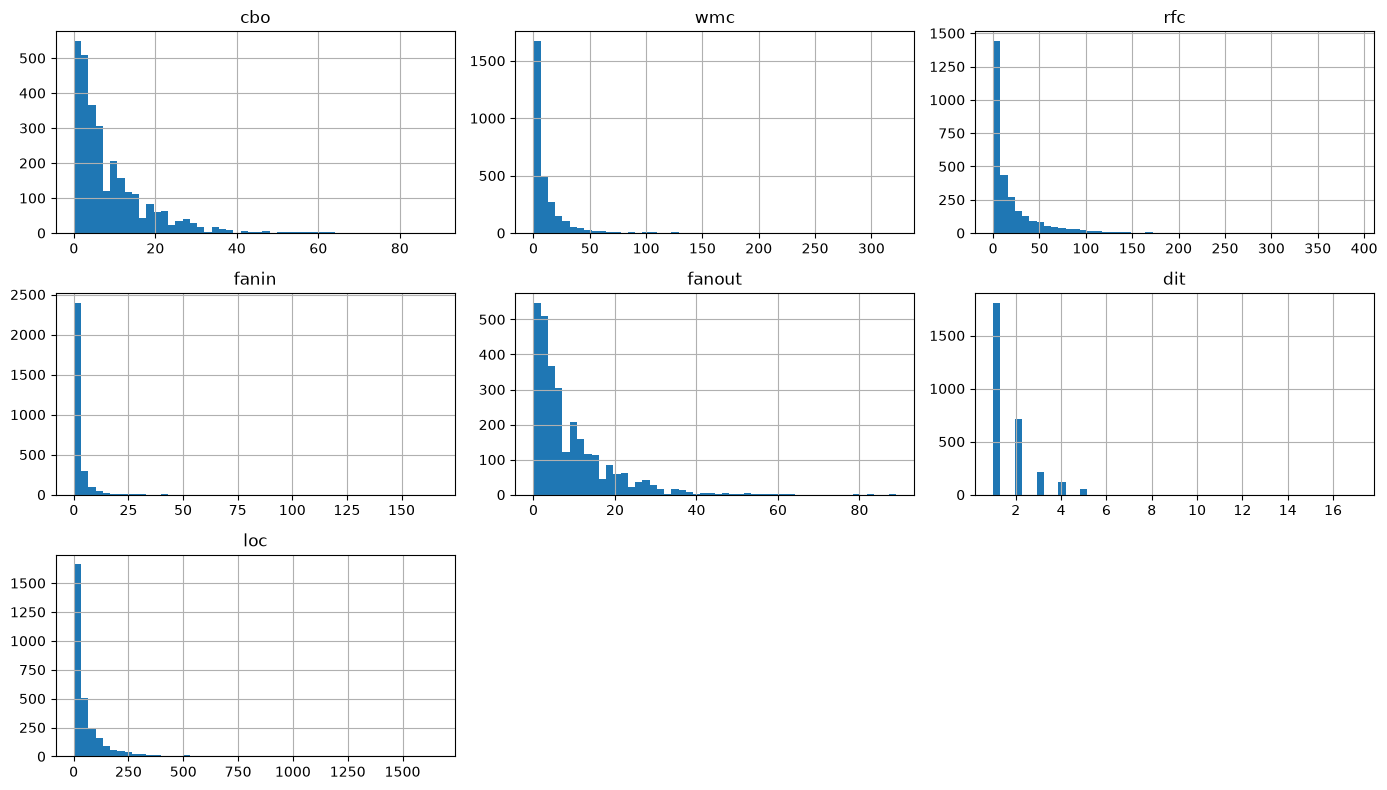

In [14]:
df_class[FEATURES].hist(bins = 50, figsize = (14, 8))
plt.tight_layout()
plt.show()

In [17]:
df_class[FEATURES].isnull().sum()

cbo       0
wmc       0
rfc       0
fanin     0
fanout    0
dit       0
loc       0
dtype: int64

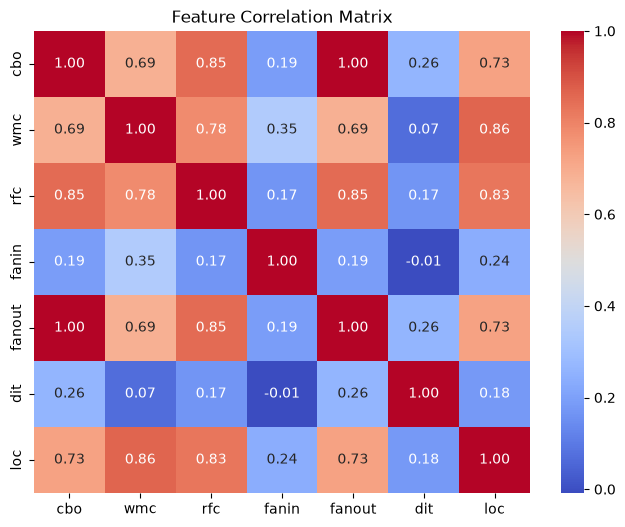

In [19]:
plt.figure(figsize = (8, 6))
sns.heatmap(df_class[FEATURES].corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [20]:
df_class = df_class[df_class['file'].str.contains('src/main/java', na=False)]
print(df_class.shape)

(2152, 52)


In [21]:
df_method = pd.read_csv('data/method.csv')
print(df_method.shape)
df_method.head()

(18869, 34)


,file,class,method,constructor,line,cbo,cboModified,fanin,fanout,wmc,...,assignmentsQty,mathOperationsQty,maxNestedBlocksQty,anonymousClassesQty,innerClassesQty,lambdasQty,uniqueWordsQty,modifiers,logStatementsQty,hasJavaDoc
0,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.io.storage.row.parquet.Parquet...,write/2[org.apache.hudi.io.storage.row.parquet...,False,224,1,0,0,0,1,...,0,0,0,0,0,0,4,1,0,False
1,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.io.storage.row.parquet.Parquet...,write/2[org.apache.hudi.io.storage.row.parquet...,False,229,1,0,0,0,1,...,0,0,0,0,0,0,4,1,0,False
2,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.utilities.sources.TestSqlSource,testSqlSourceCheckpoint/0,False,147,5,3,0,3,1,...,3,0,0,0,0,0,29,1,0,True
3,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.utilities.sources.TestSqlSource,testSqlSourceMoreRecordsThanSourceLimit/0,False,164,5,3,0,3,1,...,3,0,0,0,0,0,32,1,0,True
4,/tmp/torko/4e1a1361-f9ce-4c4c-8dc8-405ce37d2ce...,org.apache.hudi.utilities.sources.TestSqlSource,initClass/0,False,62,2,1,0,1,1,...,0,0,0,0,0,0,3,9,0,False


In [22]:
print(df_method['wmc'].describe())

count    18869.000000
mean         1.788966
std          2.265826
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         69.000000
Name: wmc, dtype: float64
